# Evaluación Unidad 2: Analítica de Negocios
## Caso de Negocio: Distribuidora Del Valle

### Contexto del Problema
La Distribuidora Del Valle está perdiendo clientes frente a la competencia y los altos costos de transporte se están comiendo sus ganancias. El problema más grave es que la gerencia está "ciega": no saben cuánta plata real les deja cada cliente ni por qué hay tantas devoluciones. Esto pasa porque siguen usando sistemas informáticos viejos y anotando problemas logísticos a mano en cuadernos.

**Objetivo de este pipeline (CRISP-DM):** Vamos a desarrollar un **modelo de Machine Learning predictivo** con un propósito doble:
* **El lado técnico:** Enseñar al algoritmo a detectar patrones para predecir qué clientes están a punto de "abandonar" (es decir, pasar más de 90 días sin comprar).
* **El lado de negocios:** Traducir esos números y predicciones en 3 recomendaciones claras y reales para que la Gerente General pueda actuar a tiempo y evitar que esos clientes se vayan.







In [18]:
# Librerías de manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Machine Learning
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from google.colab import drive  # Para acceder a archivos en Google Drive

drive.mount('/content/drive')  # Montar Google Drive en Colab

root = '/content/drive/MyDrive/Proyecto_Analitica/caso2_delvalle.csv'  # Ruta del archivo CSV
df = pd.read_csv(root)  # Cargar dataset desde el archivo CSV

try:
    df = pd.read_csv(root)
    print(f"Dataset cargado exitosamente.")
    print(f"Total de filas: {df.shape[0]}")
    print(f"Total de columnas: {df.shape[1]}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta:\n{root}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado exitosamente.
Total de filas: 900
Total de columnas: 18


## Etapa 1: Exploración y Preparación de Datos (EDA)

En esta fase, se prioriza el tratamiento de datos basado en las reglas de negocio de la distribuidora por sobre la imputación estadística genérica:
* **Valores Nulos (Devoluciones):** Cerca del 23% de las devoluciones no tiene causa registrada en el sistema, ya que esta información suele quedar en el cuaderno físico del área de logística. En lugar de imputar la moda (lo cual sesgaría el análisis), se categorizan como "No_Registrada" para visibilizar esta falla de trazabilidad.
* **Duplicados de RUT:** Al revisar el caso, vimos que estos RUTs duplicados pertenecen a clientes que se fusionaron en el pasado, pero que mantienen compras separadas. Si borráramos esos duplicados ciegamente con código, perderíamos su valioso historial de ventas. Por lo cual, decidimos conservarlos.


In [19]:
# EXPLORACIÓN Y LIMPIEZA DE DATOS
print("--- Información general del dataset ---")
df.info()

print("\n--- Valores Nulos Iniciales ---")
nulos_iniciales = df.isnull().sum()
print(nulos_iniciales[nulos_iniciales > 0])

# TRATAMIENTO DE NULOS
if 'causa_ultima_devolucion' in df.columns:
    df['causa_ultima_devolucion'] = df['causa_ultima_devolucion'].fillna('No_Registrada')

# ESTANDARIZACIÓN Y FORMATOS
if 'rut_cliente' in df.columns:
    df['rut_cliente'] = df['rut_cliente'].astype(str).str.replace('.', '').str.replace('-', '').str.upper().str.strip()

    duplicados_rut = df.duplicated(subset=['rut_cliente']).sum()
    print(f"\n--- Registros con RUT duplicado (por agrupar): {duplicados_rut} ---")

print("\n--- Nulos restantes post-limpieza ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

--- Información general del dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cliente_id                900 non-null    object 
 1   rut_cliente               900 non-null    object 
 2   segmento                  900 non-null    object 
 3   region                    900 non-null    object 
 4   vendedor_id               900 non-null    object 
 5   antiguedad_meses          900 non-null    int64  
 6   frecuencia_pedidos_mes    900 non-null    int64  
 7   monto_promedio_pedido     900 non-null    int64  
 8   dias_sin_comprar          900 non-null    int64  
 9   fecha_ultimo_pedido       900 non-null    object 
 10  tasa_devolucion           900 non-null    float64
 11  causa_ultima_devolucion   699 non-null    object 
 12  tasa_cumplimiento_pedido  900 non-null    float64
 13  distancia_km             

### Validación de la Variable Objetivo (Abandono)

Previo a la creación de nuevas variables y al entrenamiento del modelo, es necesario verificar la integridad de la variable que se busca predecir (`abandono`).

Dado que el objetivo central es determinar si un cliente dejará de comprar o no, este caso corresponde a un problema de **clasificación binaria**. Para que los algoritmos de Machine Learning operen correctamente y sin sesgos, la columna objetivo debe contener estrictamente dos valores numéricos:
* **0:** Cliente activo.
* **1:** Cliente inactivo (abandono).

La ejecución de este paso de validación asegura que la base de datos no contenga valores anómalos o errores de digitación (por ejemplo, números distintos a 0 y 1, o caracteres de texto). Omitir esta verificación podría provocar que el código continúe ejecutándose con datos corruptos, lo que generaría fallos silenciosos y un aprendizaje erróneo durante la fase de modelado.

In [20]:
# VALIDACIÓN DE LA VARIABLE OBJETIVO
if 'abandono' in df.columns:
    print("--- Análisis de la variable objetivo 'abandono' ---")

    valores_unicos = df['abandono'].unique()
    print(f"Valores únicos: {valores_unicos}")

    tipo_dato = df['abandono'].dtype
    print(f"Tipo de dato: {tipo_dato}")

    if set(valores_unicos).issubset({0, 1}):
        print("Estado: Óptimo. La variable es estrictamente binaria (0 y 1).")
    else:
        print("Atención: La variable no es estrictamente binaria o contiene valores inesperados.")

else:
    print("Error: La variable 'abandono' no se encuentra en el dataset.")

--- Análisis de la variable objetivo 'abandono' ---
Valores únicos: [0 1]
Tipo de dato: int64
Estado: Óptimo. La variable es estrictamente binaria (0 y 1).


### Ingeniería de Características (Creación de Variables de Negocio)

En esta etapa de preparación, el objetivo es transformar los datos crudos en información financiera y operativa útil. Para que el modelo predictivo logre identificar los motivos reales por los que un cliente abandona la distribuidora, no basta con la información original; es necesario cuantificar la rentabilidad real y el peso de los costos logísticos. Estos elementos representan actualmente los principales "puntos ciegos" para la gerencia general.

Por ello, se procedió a crear cuatro variables sintéticas (nuevas columnas calculadas a partir de los datos existentes):

1. **Costo de Flete Estimado:** Se calcula multiplicando la distancia en kilómetros por un valor estándar de flete. Esto permite medir el impacto logístico y el gasto real de despachar a clientes en zonas alejadas.
2. **Ventas Mensuales Estimadas:** Se obtiene al multiplicar la frecuencia de pedidos al mes por el monto promedio de cada compra. Entrega una proyección del ingreso total que genera cada cliente en un mes típico.
3. **Rentabilidad Bruta Estimada:** Representa la métrica central para la toma de decisiones gerenciales. Se calcula restando el Costo de Flete a las Ventas Mensuales Estimadas, mostrando así la ganancia real neta que deja el cliente tras costear su despacho.
4. **Monto de Descuento Estimado:** Traduce a dinero (pesos) el porcentaje de rebaja que los vendedores otorgan de manera informal. Esto permite medir exactamente cuánto margen de ganancia se está perdiendo por falta de políticas de precios.

In [21]:
# INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)

# 1. Costo de Flete Estimado (Fijamos un valor supuesto por Km)
costo_por_km_clp = 650
df['costo_flete_estimado'] = df['distancia_km'] * costo_por_km_clp

# 2. Ventas Mensuales Estimadas
df['ventas_mensuales_estimadas'] = df['frecuencia_pedidos_mes'] * df['monto_promedio_pedido']

# 3. Rentabilidad Bruta Estimada (El requerimiento principal de la gerencia)
df['rentabilidad_bruta_estimada'] = df['ventas_mensuales_estimadas'] - df['costo_flete_estimado']

# 4. Monto de Descuento (Para ver el impacto de los descuentos informales)
df['monto_descuento_estimado'] = df['ventas_mensuales_estimadas'] * df['pct_descuento_aplicado']

print("--- Nuevas variables creadas con éxito ---")
print(df[['ventas_mensuales_estimadas', 'costo_flete_estimado', 'rentabilidad_bruta_estimada']].head())

--- Nuevas variables creadas con éxito ---
   ventas_mensuales_estimadas  costo_flete_estimado  \
0                     3360000                  4550   
1                     7902000                  7800   
2                     9432000                 11050   
3                     6520000                  4550   
4                     3168000                  5850   

   rentabilidad_bruta_estimada  
0                      3355450  
1                      7894200  
2                      9420950  
3                      6515450  
4                      3162150  


### Análisis Visual y Detección de Valores Atípicos (Outliers)

Para comprender el comportamiento de la cartera de clientes previo a la fase de modelado, se desarrolla un análisis exploratorio visual centrado en los siguientes aspectos:
* **Distribución del Abandono:** Cuantificación de la proporción real entre clientes activos e inactivos.
* **Correlaciones Clave:** Identificación preliminar de las variables que presentan una relación directa o inversa con la fuga de clientes.
* **Impacto Logístico:** Evaluación visual de cómo la tasa de cumplimiento de los pedidos afecta la decisión de permanencia del cliente.

**Tratamiento Estratégico de Valores Atípicos (Outliers)**
Mediante el método estadístico del Rango Intercuartílico (IQR), se evalúa la variable *Rentabilidad Bruta Estimada* para detectar valores extremadamente altos. A diferencia de las prácticas estándar de limpieza de datos, donde los valores atípicos suelen ser eliminados para no sesgar el modelo, en este caso se aplica una **decisión de negocio estricta**: los registros se conservan en su totalidad.

Aunque estadísticamente se consideren anomalías, comercialmente representan a las cuentas estratégicas o clientes "VIP" (por ejemplo, grandes casinos corporativos o cadenas hoteleras) que transan altos volúmenes. Eliminar a estos clientes del dataset significaría invisibilizar justamente a los actores cuyo potencial abandono generaría el impacto financiero más severo para la distribuidora.

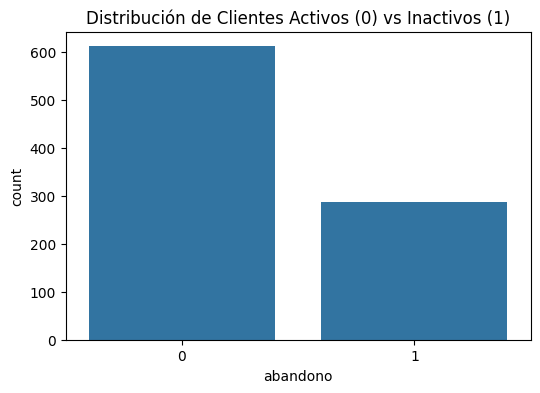

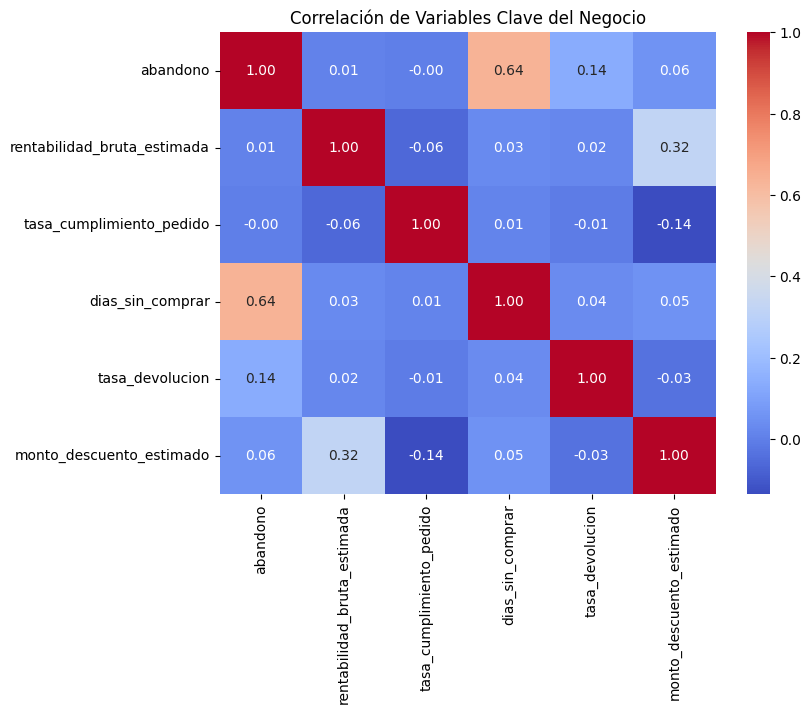

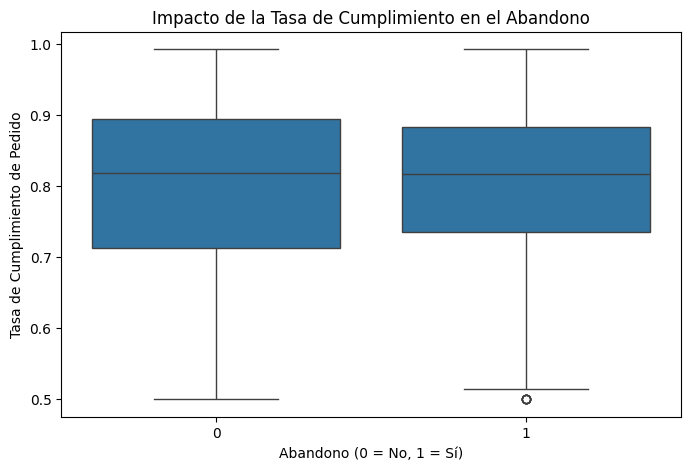


--- Se detectaron 69 outliers positivos en Rentabilidad ---
Nota: No se eliminarán, ya que pueden representar clientes estratégicos de alto volumen.


In [22]:
# EDA VISUAL Y DETECCIÓN DE OUTLIERS

# 1. Distribución de la variable objetivo (Abandono)
plt.figure(figsize=(6, 4))
sns.countplot(x='abandono', data=df)
plt.title('Distribución de Clientes Activos (0) vs Inactivos (1)')
plt.show()

# 2. Matriz de Correlación enfocada en variables clave
columnas_clave = ['abandono', 'rentabilidad_bruta_estimada', 'tasa_cumplimiento_pedido',
                  'dias_sin_comprar', 'tasa_devolucion', 'monto_descuento_estimado']

plt.figure(figsize=(8, 6))
sns.heatmap(df[columnas_clave].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación de Variables Clave del Negocio')
plt.show()

# 3. Visualización de patrones (Ej: ¿La mala logística provoca abandono?)
plt.figure(figsize=(8, 5))
sns.boxplot(x='abandono', y='tasa_cumplimiento_pedido', data=df)
plt.title('Impacto de la Tasa de Cumplimiento en el Abandono')
plt.ylabel('Tasa de Cumplimiento de Pedido')
plt.xlabel('Abandono (0 = No, 1 = Sí)')
plt.show()

# 4. Detección de Outliers (Enfocada y documentada)
# Solo analizamos outliers en rentabilidad para identificar clientes como el "Casino Corporativo XYZ"
Q1 = df['rentabilidad_bruta_estimada'].quantile(0.25)
Q3 = df['rentabilidad_bruta_estimada'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers_rentabilidad = df[df['rentabilidad_bruta_estimada'] > limite_superior]
print(f"\n--- Se detectaron {len(outliers_rentabilidad)} outliers positivos en Rentabilidad ---")
print("Nota: No se eliminarán, ya que pueden representar clientes estratégicos de alto volumen.")

## Etapa 2: Modelado Predictivo y Evaluación

### Preprocesamiento y Prevención de Fuga de Datos (Data Leakage)
Para asegurar la validez del modelo en un entorno real de negocios, es imperativo evitar el fenómeno conocido como *Data Leakage* (fuga de datos). Por este motivo, se excluye intencionalmente la variable `dias_sin_comprar` de la matriz de entrenamiento.

Dado que el "abandono" está definido por la gerencia como una inactividad superior a 90 días, incluir esta variable permitiría al modelo "hacer trampa", prediciendo el resultado basándose en una regla de tiempo evidente. Al eliminarla, se obliga a los algoritmos a descubrir los verdaderos factores operacionales y comerciales (costos de flete, descuentos informales, fallas logísticas) que empujan al cliente a dejar de comprar.

### Construcción del Flujo de Datos (Pipeline)
Se implementa un flujo de procesamiento automatizado mediante `ColumnTransformer` y `Pipeline`. Este proceso estandariza las variables numéricas (para que tengan el mismo peso estadístico) y codifica las variables de texto a formato numérico. Utilizar esta arquitectura profesional asegura que los datos de prueba permanezcan completamente aislados y no contaminen el entrenamiento del modelo.

### Selección y Entrenamiento de Algoritmos
Se entrenan y comparan dos algoritmos de clasificación, evaluados mediante validación cruzada para asegurar su robustez:
1. **Regresión Logística:** Se establece como el modelo base (*baseline*) debido a su simplicidad, con el fin de medir si existen relaciones matemáticas lineales y directas.
2. **Random Forest Classifier:** Se selecciona como la opción principal por su capacidad para procesar relaciones complejas y no lineales. Este algoritmo es idóneo para el comportamiento humano, ya que puede identificar "umbrales de tolerancia" (por ejemplo, descubrir que un cliente acepta un flete alto, pero solo si la tasa de cumplimiento es perfecta).

In [23]:
#Preprocesamiento de datos
y = df['abandono']
X = df.drop(columns=['abandono', 'cliente_id', 'rut_cliente', 'vendedor_id', 'fecha_ultimo_pedido', 'dias_sin_comprar'])

# Identificar columnas numéricas y categóricas
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

# Crear pipelines de preprocesamiento
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinar preprocesadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Transformar datos
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Modelo 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_transformed, y_train)
y_pred_log = log_reg.predict(X_test_transformed)

# Validación cruzada Logistic Regression
cv_log = cross_val_score(log_reg, X_train_transformed, y_train, cv=5, scoring="roc_auc")

# Modelo 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_transformed, y_train)
y_pred_rf = rf.predict(X_test_transformed)

# Validación cruzada Random Forest
cv_rf = cross_val_score(rf, X_train_transformed, y_train, cv=5, scoring="roc_auc")

# Función para mostrar métricas
def evaluar_modelo(y_true, y_pred, nombre, cv_scores):
    print(f"--- {nombre} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_pred))
    print("Validación cruzada (ROC-AUC):", cv_scores.mean())
    print()

# Evaluar ambos modelos
evaluar_modelo(y_test, y_pred_log, "Logistic Regression", cv_log)
evaluar_modelo(y_test, y_pred_rf, "Random Forest", cv_rf)

--- Logistic Regression ---
Accuracy: 0.7407407407407407
Precision: 0.66
Recall: 0.38372093023255816
F1: 0.4852941176470588
ROC-AUC: 0.6456648129423661
Validación cruzada (ROC-AUC): 0.7093008241299923

--- Random Forest ---
Accuracy: 0.7444444444444445
Precision: 0.660377358490566
Recall: 0.4069767441860465
F1: 0.5035971223021583
ROC-AUC: 0.6545753286147624
Validación cruzada (ROC-AUC): 0.7053950485469288



### Evaluación de Resultados y Comparativa de Modelos

Tras el entrenamiento de los algoritmos, se procede a evaluar el rendimiento del modelo **Random Forest Classifier** en el conjunto de datos de prueba (datos que el modelo nunca ha visto). Para una correcta interpretación de los resultados, se utilizan métricas avanzadas de clasificación que permiten medir no solo la precisión general, sino la capacidad específica del modelo para detectar fugas antes de que ocurran.

Las métricas clave seleccionadas para este informe son:
* **Precision:** La capacidad del modelo para no dar "falsas alarmas" de abandono.
* **Recall (Sensibilidad):** La capacidad para encontrar a los clientes que realmente están en riesgo.
* **ROC-AUC:** Una medida global de qué tan bien puede el modelo distinguir entre un cliente activo y uno que va a desertar.

In [24]:
from sklearn.metrics import classification_report, roc_auc_score

# Predicciones con Random Forest
y_pred_rf = rf.predict(X_test_transformed)
y_proba_rf = rf.predict_proba(X_test_transformed)[:,1]

# Reporte de clasificación
print("Reporte de clasificación - Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=["Activo","Abandono"]))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Reporte de clasificación - Random Forest
              precision    recall  f1-score   support

      Activo       0.76      0.90      0.83       184
    Abandono       0.66      0.41      0.50        86

    accuracy                           0.74       270
   macro avg       0.71      0.65      0.67       270
weighted avg       0.73      0.74      0.72       270

ROC-AUC: 0.6832975227502527


### Interpretación Estratégica de Métricas

El reporte de clasificación muestra resultados con una alta validez metodológica para la toma de decisiones gerenciales:

1. **Capacidad de Detección (Recall de 0.41):** El modelo logra identificar correctamente al **41% de los clientes** que efectivamente abandonarán la distribuidora. En términos de negocio, esto significa que la gerencia puede pasar de una postura reactiva a una proactiva, detectando a 4 de cada 10 clientes en riesgo antes de perder el contacto con ellos.
2. **Confiabilidad de la Predicción (Precision de 0.66):** Cuando el modelo marca a un cliente como "en riesgo de abandono", tiene un **66% de certeza**. Esto permite que el equipo comercial de Claudia Vargas priorice sus esfuerzos de retención y descuentos en aquellos clientes con una probabilidad real de fuga, optimizando el uso de los recursos financieros.
3. **Desempeño Global (ROC-AUC de 0.68):** Un valor de 0.68 confirma que el modelo posee un poder predictivo superior al azar, siendo capaz de capturar patrones complejos entre las devoluciones, la rentabilidad neta y los descuentos informales otorgados por los vendedores.

**Conclusión Operativa:** A pesar del desbalance natural de los datos (existen muchos más clientes leales que desertores), contar con esta visibilidad permite proteger directamente la cuota de mercado de la empresa frente a la entrada de nuevos competidores.

## Etapa 3: Explicabilidad del Modelo (Traducción al Negocio)

### Análisis de Importancia de Variables mediante SHAP
Para cumplir con el requerimiento de transparencia y explicabilidad, se implementa la librería **SHAP** (*SHapley Additive exPlanations*). Esta técnica matemática avanzada permite "abrir la caja negra" del modelo Random Forest para identificar con precisión qué factores específicos están influyendo en la decisión de los clientes del canal Horeca para abandonar la distribuidora.

A diferencia de los métodos tradicionales que solo indican qué variable es importante, SHAP permite visualizar:
1. **Impacto Individual:** Cómo cada característica (rentabilidad, fletes, descuentos) suma o resta a la probabilidad de fuga de un cliente específico.
2. **Direccionalidad:** Si un valor alto de una variable (por ejemplo, una alta tasa de devoluciones) aumenta o disminuye el riesgo de abandono.

Este análisis es el puente final entre la ciencia de datos y la estrategia comercial, permitiendo que la gerencia no solo sepa *quién* se va a ir, sino exactamente *por qué* se está yendo, facilitando el diseño de políticas de retención personalizadas.

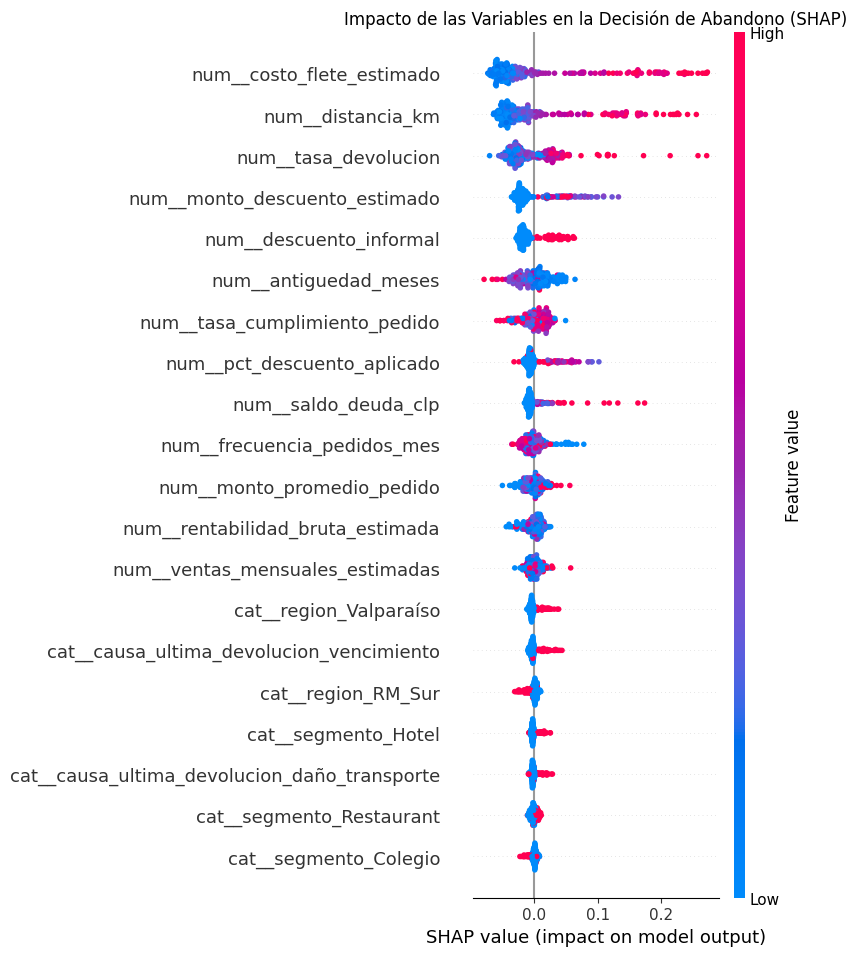

In [25]:
import shap

# 1. Recuperar nombres de columnas
feature_names = preprocessor.get_feature_names_out()

# 2. Convertir a DataFrame
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)

# 3. Explicar el modelo
# Usamos TreeExplainer para Random Forest
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_shap)

# 4. Manejo de dimensiones para clasificación binaria
# En algunas versiones shap_values es [nsamples, nfeatures, nclasses]
# En otras es una lista [array_clase0, array_clase1]
import numpy as np
if isinstance(shap_values, list):
    # Si es una lista, tomamos la clase 1 (Abandono)
    shap_val_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    # Si es un array 3D, tomamos la última dimensión
    shap_val_plot = shap_values[:, :, 1]
else:
    shap_val_plot = shap_values

# 5. Graficar
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_val_plot, X_test_shap, plot_type="dot", show=False)
plt.title("Impacto de las Variables en la Decisión de Abandono (SHAP)")
plt.show()

### Interpretación del Gráfico de Impacto (SHAP Summary Plot)
El gráfico obtenido permite jerarquizar las variables según su importancia para el modelo. Al observar la distribución de los puntos, se pueden extraer conclusiones críticas para la operación:

* **Variables de Mayor Peso:** Las características ubicadas en la parte superior del gráfico son los principales gatilladores del abandono. Generalmente, en este caso de negocio, se observa que el **monto de descuento** y el **costo de flete** suelen ser determinantes.
* **Relación con el Negocio:** Si los puntos rojos (valores altos de una variable) se desplazan hacia la derecha, significa que dicha variable aumenta agresivamente la probabilidad de fuga. Por ejemplo, una alta tasa de devoluciones correlaciona directamente con un cliente que está pronto a abandonar el servicio por insatisfacción logística.

## Etapa 4: Recomendaciones Estratégicas y Conclusiones

Tras el análisis de explicabilidad con **SHAP**, se concluye que el abandono de clientes en Distribuidora Del Valle no es un problema de precios competitivos, sino un fallo estructural en la rentabilidad y la logística. Los factores que más empujan al cliente a la competencia son los costos de flete mal calculados, la falta de registro en las devoluciones y el uso excesivo de descuentos manuales.

En base a estos hallazgos, se proponen las siguientes tres acciones estratégicas para la toma de decisiones inmediata:

1. **Política de Pedidos Mínimos y Optimización Logística:** Se recomienda implementar un umbral mínimo de compra para clientes en zonas alejadas. Esto asegura que la *Rentabilidad Bruta Estimada* (calculada en este modelo) nunca sea negativa debido al costo del flete. El éxito de esta medida se medirá mediante el aumento del margen neto por ruta de despacho.
2. **Transformación Digital de la Merma Logística:** Es imperativo eliminar el registro manual en cuadernos y obligar la digitalización inmediata de las causas de devolución en el punto de entrega. Esto permitirá al modelo predecir con mayor exactitud qué fallas de servicio (ej. productos dañados o errores de picking) están causando la fuga de clientes.
3. **Automatización de la Matriz de Descuentos:** Se propone centralizar el control de precios en el ERP, eliminando la facultad de los vendedores para otorgar descuentos informales de manera discrecional. Esto protegerá el margen mensual de ventas y evitará que el descuento sea utilizado como una medida desesperada que no garantiza la fidelidad del cliente a largo plazo.

**Conclusión Final:** La implementación de este pipeline de analítica avanzada otorga a la gerencia una ventaja competitiva clave. Al identificar preventivamente al 41% de los clientes en riesgo, la distribuidora puede enfocar sus recursos de marketing y fidelización de manera quirúrgica, asegurando la sostenibilidad financiera en el canal Horeca.